# Netflix Data Analysis Project

- Numpy
- Pandas
- Matplotlib

## Questions
1. Is Netflix content mostly movies or TV shows?
2. Which genre has the most titles?
3. Which country has produced the most Netflix content?
4. Which rating is most common?
5. Which year had the most content released?
6. How has the amount of Netflix content changed over the years?

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [66]:
df = pd.read_csv("Downloads/netflix data analysis projects/netflix_titles.csv", lineterminator = "\n")

In [67]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [68]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 3.9 MB


## Dataset 
The dataset contains information of the following:
1. Type of movie/TV Show
2. Director of the movie
3. Cast of the movie
4. Country of production
5. Date Added
6. Year released
7. Rating and duration of the movie/TV show
8. Genre
9. Description

The informations can help us recognize patterns of Netflix movies and TV Shows

In [69]:
df.isnull().sum() #finding out how many missing values there are in each column

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

## Data Cleaning 


Problems with the current dataset:
1. The director, cast, country, date_added, duration and rating columns have missing values
2. The date_added is stored as text
3. Some columns contain multiple values in a single cell
4. The cells in the duration column has multiple units

In [70]:
#filling the missing values
df['director'] = df['director'].fillna('Unavailable')
df['cast'] = df['cast'].fillna('Unavailable')
df['country'] = df['country'].fillna('Unavailable')

#as date_added and rating are important, the rows containing NaN in date_added and rating are dropped
df = df.dropna(subset = ['date_added', 'rating', 'duration']).copy()

In [71]:
#convert date_added into date
df['date_added'] = pd.to_datetime(df['date_added'], errors = 'coerce')

What does 'errors = coerce' mean?
if something cannot be converted into a date, this turns it into NaT instead of giving an error

In [72]:
#making a new column called year_added 
df['year_added'] = df['date_added'].dt.year

In [73]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unavailable,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0
1,s2,TV Show,Blood & Water,Unavailable,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unavailable,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0
3,s4,TV Show,Jailbirds New Orleans,Unavailable,Unavailable,Unavailable,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0
4,s5,TV Show,Kota Factory,Unavailable,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0


In [74]:
df.dropna(subset = ['date_added'], inplace = True)

Is Netflix content mostly movies or TV shows?

In [75]:
df['type'].value_counts()

type
Movie      6126
TV Show    2576
Name: count, dtype: int64

In [76]:
df['type'].value_counts('Movie')*100

type
Movie      70.39761
TV Show    29.60239
Name: proportion, dtype: float64

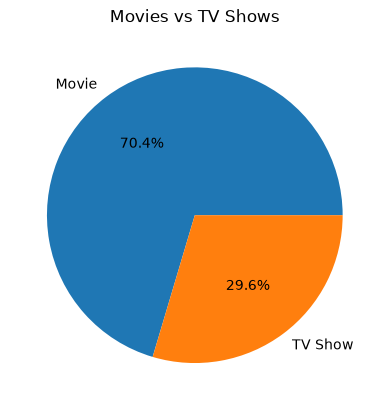

In [77]:
df['type'].value_counts().plot(kind = 'pie', autopct = '%1.1f%%')
plt.title("Movies vs TV Shows")
plt.show()

Netflix content is mostly movies

Which genre has the most titles?

In [78]:
#splitting the genres in each cell
genre = df['listed_in'].str.split(',').explode().str.strip()
#top 10 genres
top_genres = genre.value_counts().head(10)
top_genres

listed_in
International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1327
Documentaries                869
Action & Adventure           859
Independent Movies           756
TV Dramas                    739
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

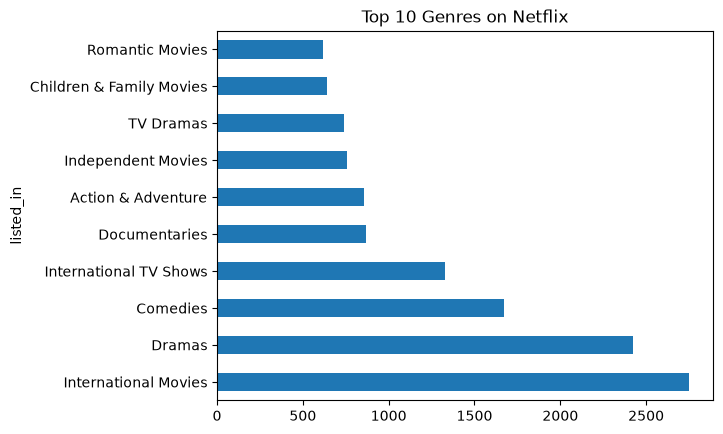

In [79]:
top_genres.plot(kind = 'barh')
plt.title("Top 10 Genres on Netflix")
plt.show()

International movies are the most popular genre on netflix

Which country has produced the most Netflix content?

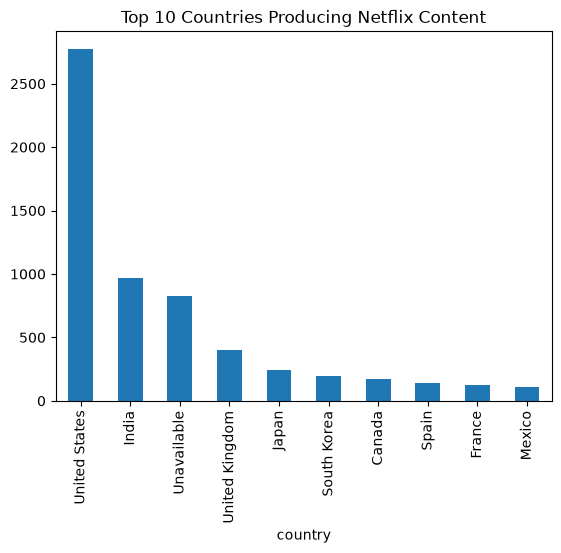

In [80]:
df['country'].value_counts().head(10).plot(kind = 'bar')
plt.title("Top 10 Countries Producing Netflix Content")
plt.show()

Which rating is most common?

In [81]:
df['rating'].value_counts()

rating
TV-MA       3183
TV-14       2133
TV-PG        838
R            799
PG-13        490
TV-Y7        330
TV-Y         300
PG           287
TV-G         212
NR            78
G             41
TV-Y7-FV       5
NC-17          3
UR             3
Name: count, dtype: int64

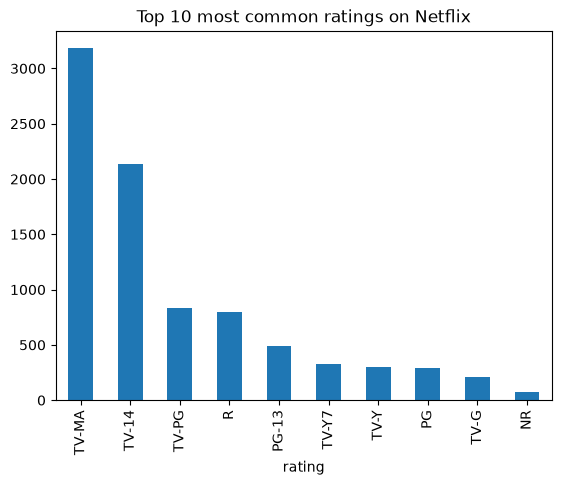

In [82]:
df['rating'].value_counts().head(10).plot(kind = 'bar')
plt.title("Top 10 most common ratings on Netflix")
plt.show()

Which year had the most content released?

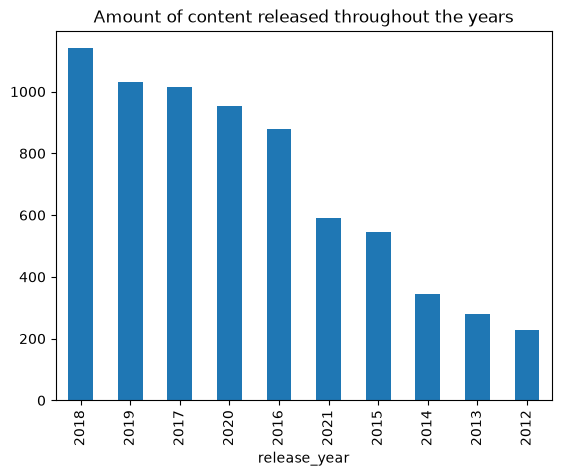

In [83]:
df['release_year'].value_counts().head(10).plot(kind = 'bar')
plt.title("Amount of content released throughout the years")
plt.show()

How has the amount of Netflix content changed over the years?

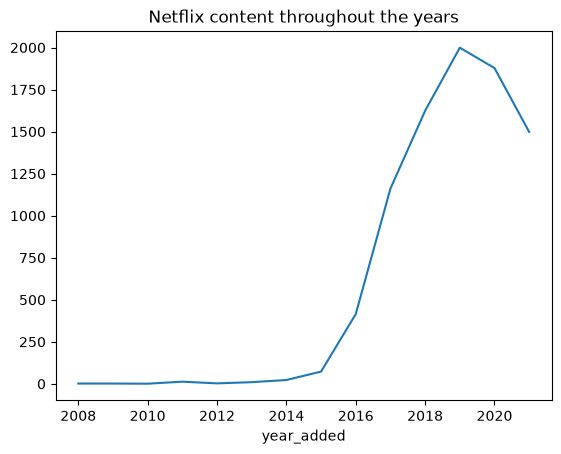

In [84]:
df['year_added'] = df['date_added'].dt.year
df['year_added'].value_counts().sort_index().plot(kind = 'line')
plt.title("Netflix content throughout the years")
plt.show()

Analysis:
- From 2008 to 2014, very few titles were added, and there was not much fluctuation
- From 2015 onwards, the amount of Netflix content added increased rapidly
- After 2019, the number of Netflix content added decreased

Which Country produced the longest movie and show?

In [90]:
info = df[['country', 'type', 'duration']]
movies = df[df['type'] == 'Movie'].copy()
shows = df[df['type'] == 'TV Show'].copy()
movies['duration_num'] = movies['duration'].apply(lambda x: int(x.split()[0]))
shows['duration_num'] = shows['duration'].apply(lambda x: int(x.split()[0]))
longest_movie = movies.loc[movies['duration_num'].idxmax()]
longest_show = shows.loc[shows['duration_num'].idxmax()]
moviecol = longest_movie[['country', 'duration']]
showcol = longest_show[['country', 'duration']]
print("Longest movie:")
print(moviecol)
print()
print("Longest show:")
print(showcol)

Longest movie:
country     United States
duration          312 min
Name: 4253, dtype: object

Longest show:
country     United States
duration       17 Seasons
Name: 548, dtype: object
